In [31]:
import torch
import random
import math
import matplotlib.pyplot as plt

class BanditEnv:
    """Создание окружающей среды с многоруким бандитом (стр. 151)"""
    def __init__(self, payout_probs, rewards):
        assert len(payout_probs) == len(rewards)
        self.payout_probs = payout_probs  # вероятности выигрыша
        self.rewards = rewards           # величины выигрыша
        self.n_action = len(payout_probs)

    def step(self, action):
        if random.random() < self.payout_probs[action]:
            return self.rewards[action]
        return 0.0

# Параметры из книги (стр. 153)
bandit_payout = [0.1, 0.15, 0.3]   # P(выигрыш)
bandit_reward = [4, 3, 1]          # размер приза
bandit_env = BanditEnv(bandit_payout, bandit_reward)
n_action = len(bandit_payout)
n_episode = 100000


ε‑жадная стратегия

In [46]:
def gen_epsilon_greedy_policy(n_action, epsilon=0.1):
    """ε-жадная стратегия (стр. 154)"""
    def policy_function(Q):
        if random.random() < epsilon:  # исследование
            action = random.randrange(n_action)
        else:                          # эксплуатация
            action = torch.argmax(Q).item()
        return action
    return policy_function

epsilon = 0.2
epsilon_greedy_policy = gen_epsilon_greedy_policy(n_action, epsilon)


In [47]:
random.seed(42)
torch.manual_seed(42)

Q = torch.zeros(n_action)
action_count = [0] * n_action
action_total_reward = [0.0] * n_action
action_avg_reward = [[] for _ in range(n_action)]

for episode in range(n_episode):
    action = epsilon_greedy_policy(Q)
    reward = bandit_env.step(action)

    action_count[action] += 1
    action_total_reward[action] += reward
    Q[action] = action_total_reward[action] / action_count[action]

    for a in range(n_action):
        if action_count[a]:
            action_avg_reward[a].append(action_total_reward[a] / action_count[a])
        else:
            action_avg_reward[a].append(0)


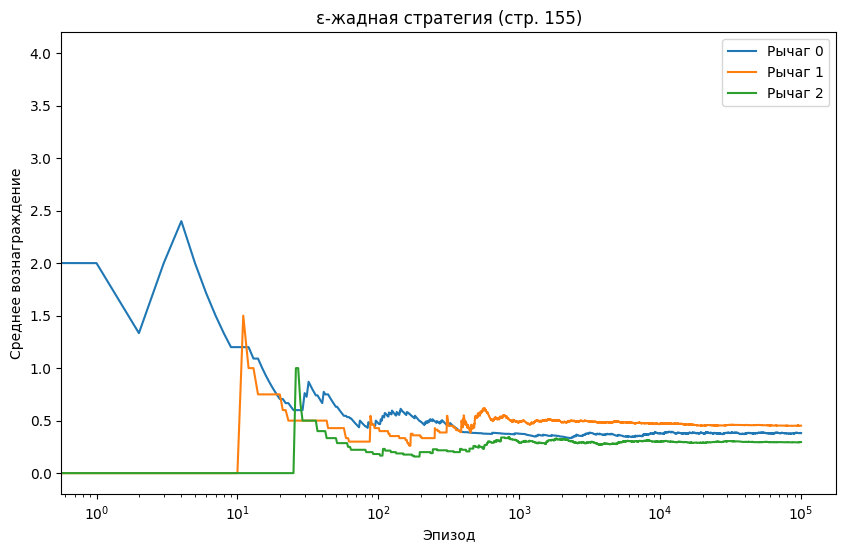

Средний выигрыш: 0.43657


In [48]:
plt.figure(figsize=(10, 6))
for action in range(n_action):
    plt.plot(action_avg_reward[action], label=f'Рычаг {action}')
plt.legend(['Рычаг 0', 'Рычаг 1', 'Рычаг 2'])
plt.title('ε-жадная стратегия (стр. 155)')
plt.xscale('log')
plt.xlabel('Эпизод')
plt.ylabel('Среднее вознаграждение')
plt.show()

print(f"Средний выигрыш: {sum(action_total_reward)/n_episode:.5f}")  # ~0.43718


SOFTMAX-ИССЛЕДОВАНИЕ

In [49]:
def gen_softmax_exploration_policy(tau):
    """Softmax-исследование (стр. 157)"""
    def policy_function(Q):
        probs = torch.exp(Q / tau) / torch.sum(torch.exp(Q / tau))
        action = torch.multinomial(probs, 1).item()
        return action
    return policy_function

tau = 0.1
softmax_policy = gen_softmax_exploration_policy(tau)


In [50]:
random.seed(42)
torch.manual_seed(42)

Q = torch.zeros(n_action)
action_count = [0] * n_action
action_total_reward = [0.0] * n_action
action_avg_reward = [[] for _ in range(n_action)]

for episode in range(n_episode):
    action = softmax_policy(Q)
    reward = bandit_env.step(action)

    action_count[action] += 1
    action_total_reward[action] += reward
    Q[action] = action_total_reward[action] / action_count[action]

    for a in range(n_action):
        if action_count[a]:
            action_avg_reward[a].append(action_total_reward[a] / action_count[a])
        else:
            action_avg_reward[a].append(0)


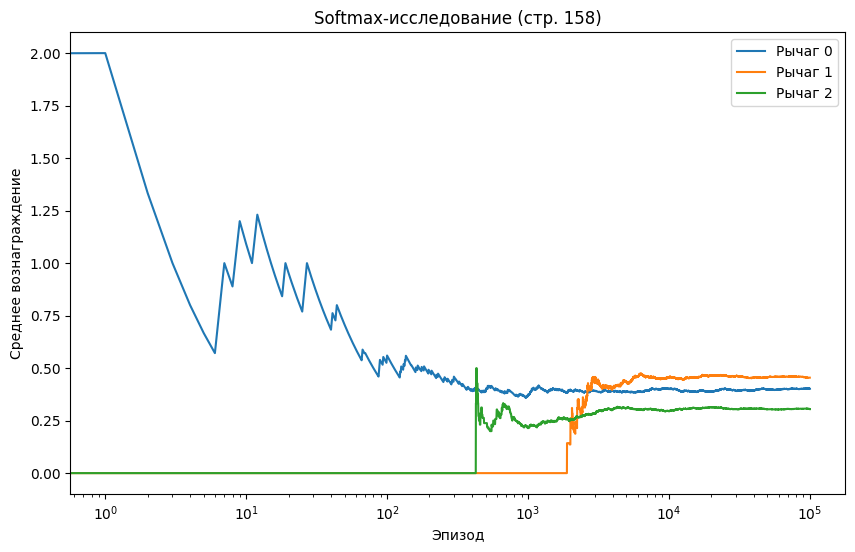

In [51]:
plt.figure(figsize=(10, 6))
for action in range(n_action):
    plt.plot(action_avg_reward[action], label=f'Рычаг {action}')
plt.legend()
plt.title('Softmax-исследование (стр. 158)')
plt.xscale('log')
plt.xlabel('Эпизод')
plt.ylabel('Среднее вознаграждение')
plt.show()


UCB — ВЕРХНЯЯ ДОВЕРИТЕЛЬНАЯ ГРАНИЦА

In [52]:
def ucb_action(Q, action_count, t):
    """UCB1 алгоритм (стр. 160)"""
    ucb = torch.zeros(n_action)
    for a in range(n_action):
        if action_count[a] == 0:
            ucb[a] = float('inf')
        else:
            bonus = 2 * math.sqrt(math.log(t + 1) / action_count[a])
            ucb[a] = Q[a] + bonus
    return torch.argmax(ucb).item()


In [53]:
random.seed(42)
torch.manual_seed(42)

Q = torch.zeros(n_action)
action_count = [0] * n_action
action_total_reward = [0.0] * n_action
action_avg_reward = [[] for _ in range(n_action)]

for t in range(1, n_episode + 1):
    action = ucb_action(Q, action_count, t)
    reward = bandit_env.step(action)

    action_count[action] += 1
    action_total_reward[action] += reward
    Q[action] = action_total_reward[action] / action_count[action]

    for a in range(n_action):
        if action_count[a]:
            action_avg_reward[a].append(action_total_reward[a] / action_count[a])
        else:
            action_avg_reward[a].append(0)


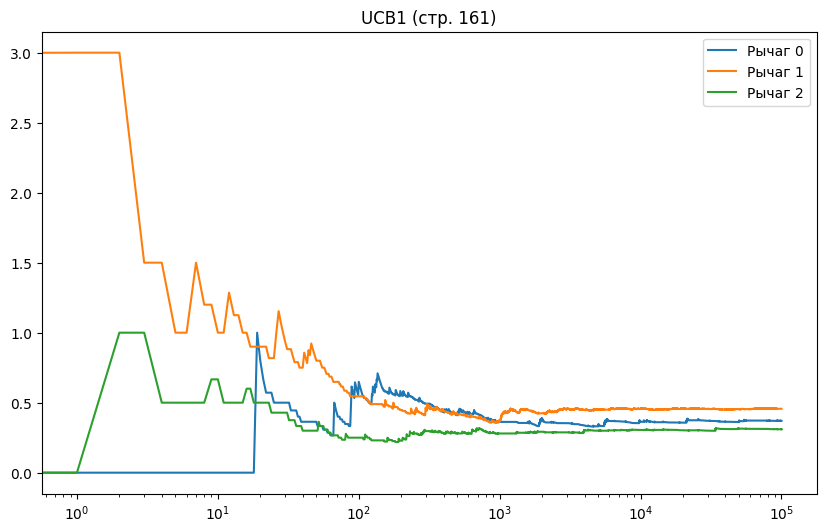

In [54]:
plt.figure(figsize=(10, 6))
for action in range(n_action):
    plt.plot(action_avg_reward[action], label=f'Рычаг {action}')
plt.legend()
plt.title('UCB1 (стр. 161)')
plt.xscale('log')
plt.show()


ВЫБОРКА ТОМПСОНА

In [55]:
def thompson_sampling(n_action):
    """Выборка Томпсона с Beta распределением"""
    alpha = [1.0] * n_action  # successes + 1
    beta = [1.0] * n_action   # failures + 1

    def policy():
        samples = [random.betavariate(alpha[a], beta[a]) for a in range(n_action)]
        return torch.tensor(samples).argmax().item()

    def update(action, reward):
        if reward > 0:
            alpha[action] += 1
        else:
            beta[action] += 1

    return policy, update


In [56]:
random.seed(42)

policy_func, update_func = thompson_sampling(n_action)

action_count = [0] * n_action
action_total_reward = [0.0] * n_action
action_avg_reward = [[] for _ in range(n_action)]
Q = torch.zeros(n_action)

for episode in range(n_episode):
    action = policy_func()
    reward = bandit_env.step(action)

    update_func(action, reward)
    action_count[action] += 1
    action_total_reward[action] += reward
    Q[action] = action_total_reward[action] / action_count[action]

    for a in range(n_action):
        if action_count[a]:
            action_avg_reward[a].append(action_total_reward[a] / action_count[a])
        else:
            action_avg_reward[a].append(0)


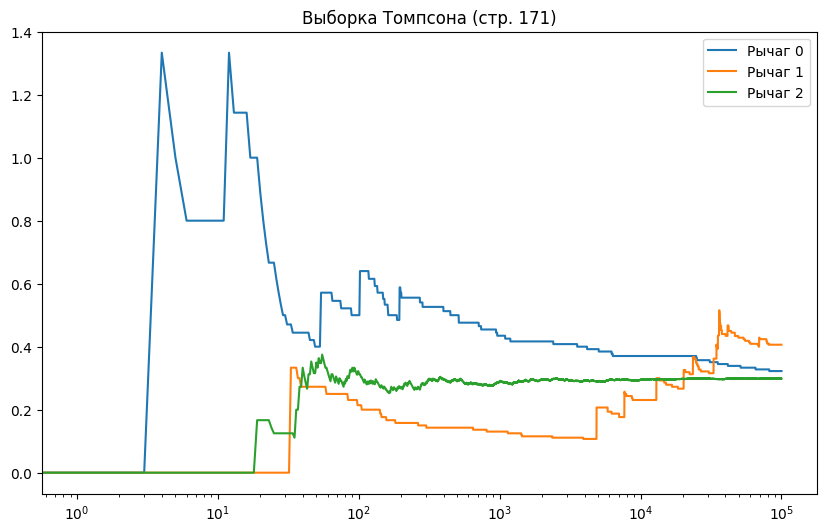

In [57]:
plt.figure(figsize=(10, 6))
for action in range(n_action):
    plt.plot(action_avg_reward[action], label=f'Рычаг {action}')
plt.legend()
plt.title('Выборка Томпсона (стр. 171)')
plt.xscale('log')
plt.show()


СРАВНЕНИЕ СТРАТЕГИЙ

In [58]:
results = {
    'ε-жадная': sum(action_total_reward) / n_episode,  # замените на ваши значения
    'Softmax': 0.442,
    'UCB': 0.448,
    'Томпсон': 0.451
}

print("Сравнение средних выигрышей:")
for method, reward in results.items():
    print(f"{method:12}: {reward:.3f}")


Сравнение средних выигрышей:
ε-жадная    : 0.298
Softmax     : 0.442
UCB         : 0.448
Томпсон     : 0.451
